In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer

In [2]:
mpg = sns.load_dataset('mpg').dropna()
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


Origin: europe, Column: mpg


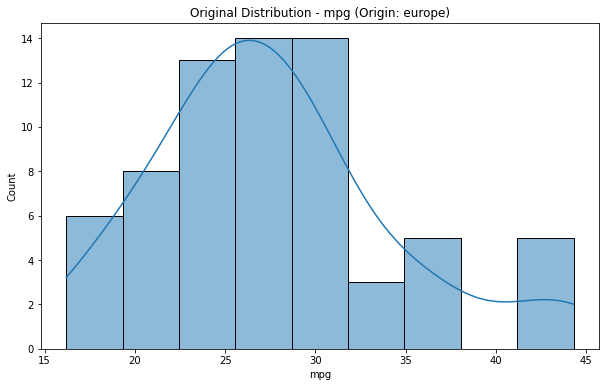

Shapiro-Wilk Test: p-value = 0.00542
mpg is not normally distributed for origin europe.


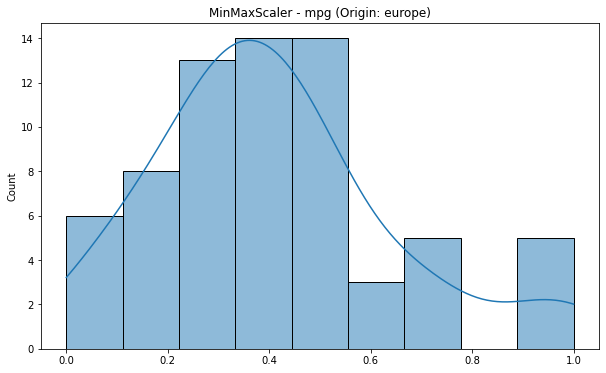

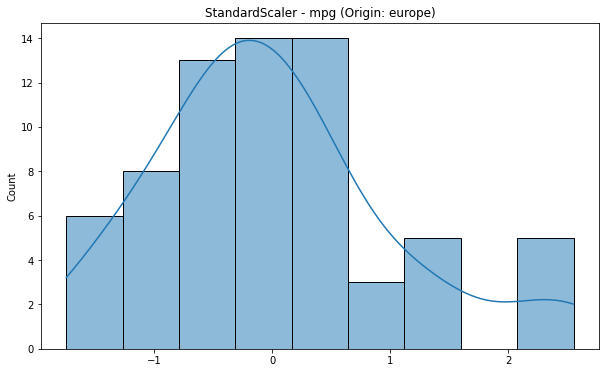

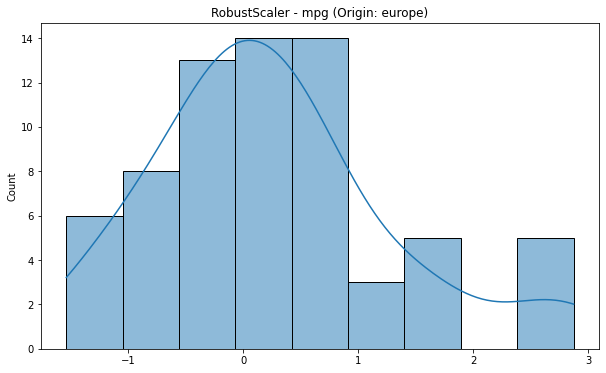

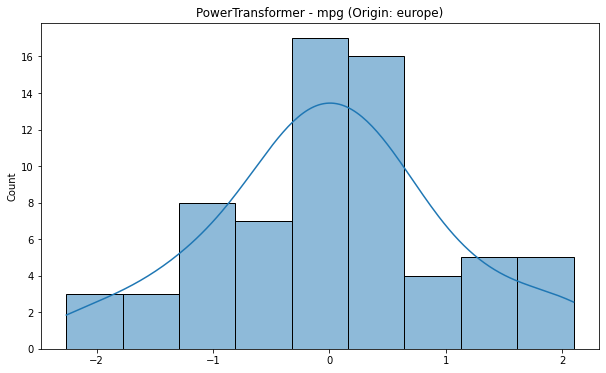

Origin: japan, Column: mpg


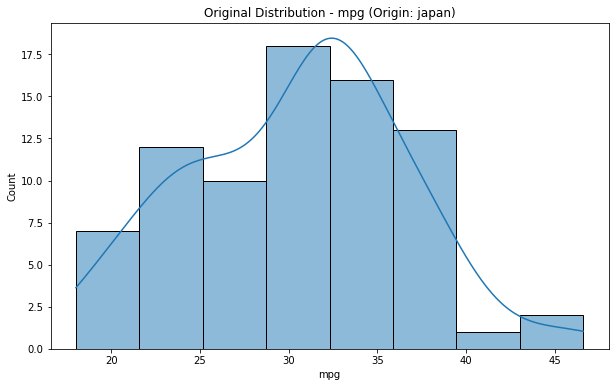

Shapiro-Wilk Test: p-value = 0.24197
mpg is normally distributed for origin japan.


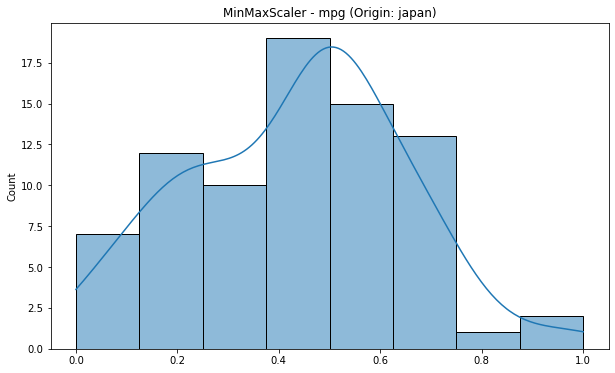

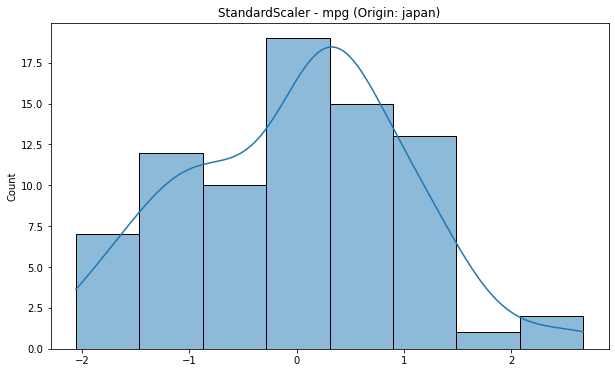

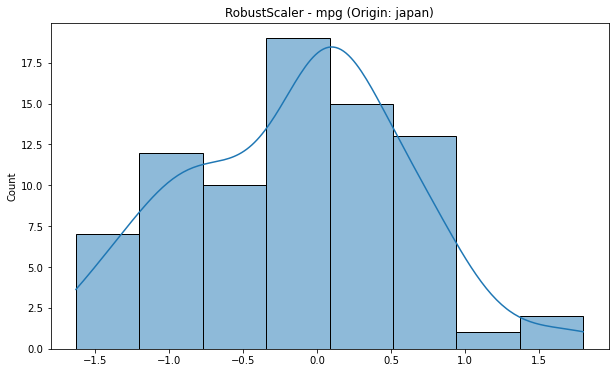

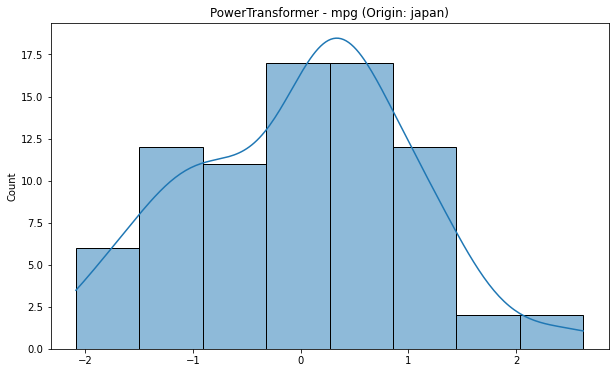

Origin: usa, Column: mpg


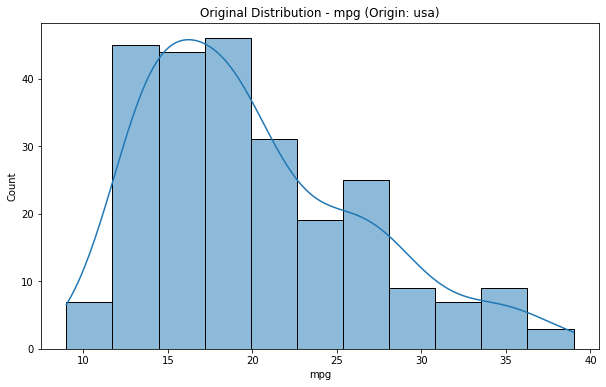

Shapiro-Wilk Test: p-value = 0.00000
mpg is not normally distributed for origin usa.


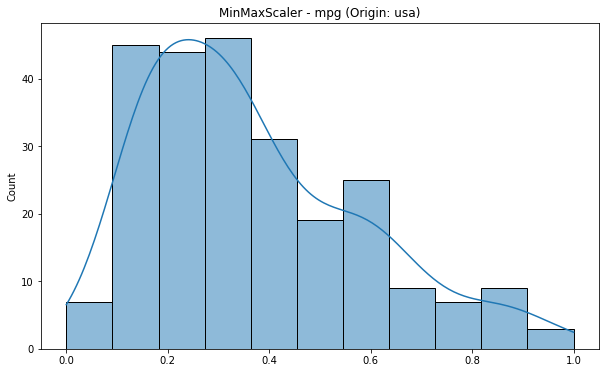

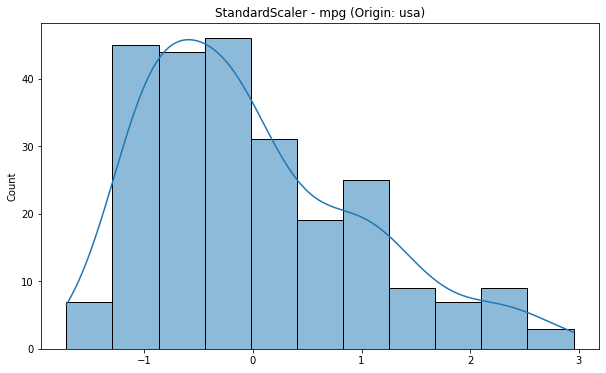

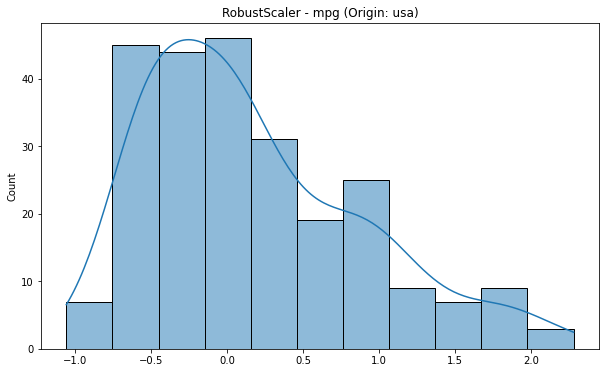

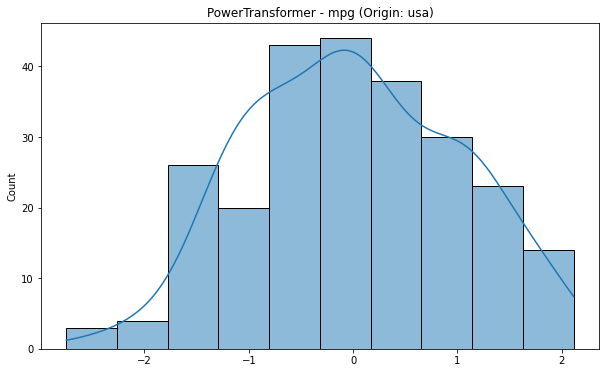

    origin            scaler          mean       std
0   europe      MinMaxScaler  4.057986e-01  0.232442
1   europe    StandardScaler  1.697988e-16  1.000000
2   europe      RobustScaler  2.514418e-01  1.024568
3   europe  PowerTransformer -2.213915e-15  1.000000
4    japan      MinMaxScaler  4.353368e-01  0.211587
5    japan    StandardScaler  1.925323e-16  1.000000
6    japan      RobustScaler -1.376488e-01  0.724716
7    japan  PowerTransformer -1.400427e-15  1.000000
8      usa      MinMaxScaler  3.677823e-01  0.214241
9      usa    StandardScaler  1.740105e-16  1.000000
10     usa      RobustScaler  1.703855e-01  0.714136
11     usa  PowerTransformer -6.380384e-16  1.000000
Origin: europe, Column: horsepower


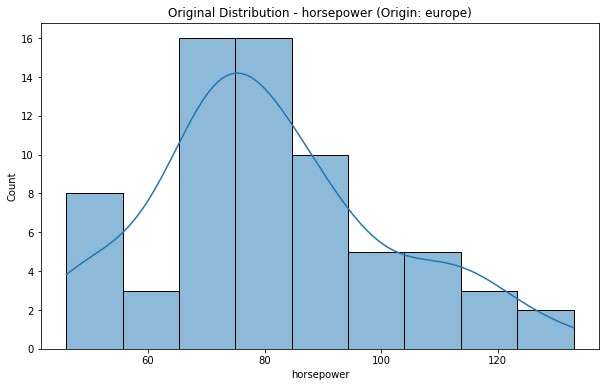

Shapiro-Wilk Test: p-value = 0.03097
horsepower is not normally distributed for origin europe.


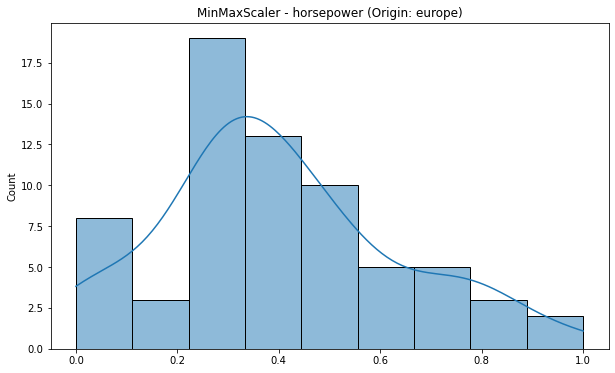

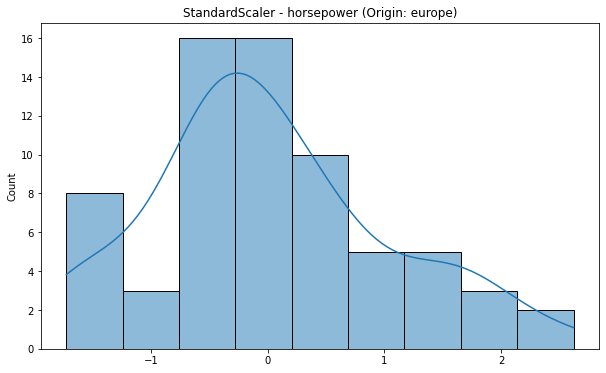

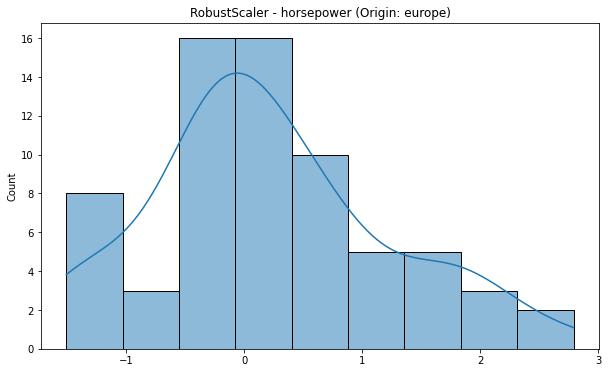

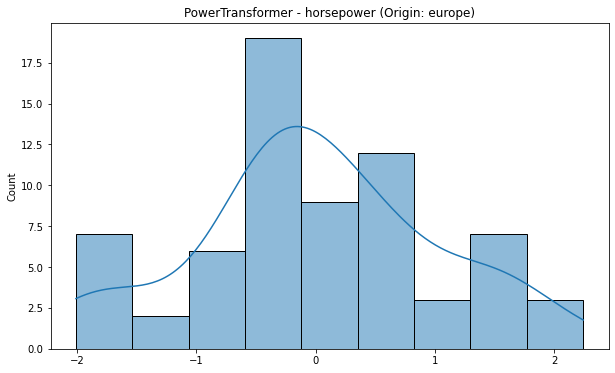

Origin: japan, Column: horsepower


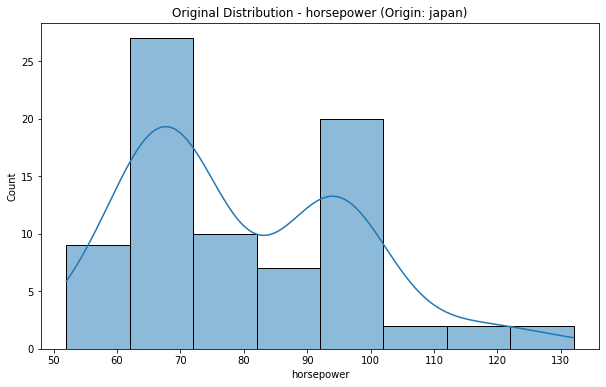

Shapiro-Wilk Test: p-value = 0.00017
horsepower is not normally distributed for origin japan.


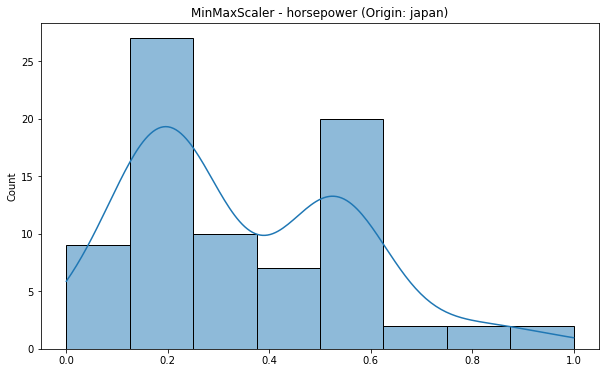

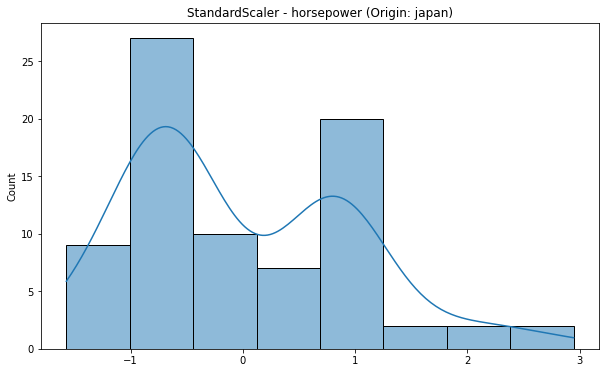

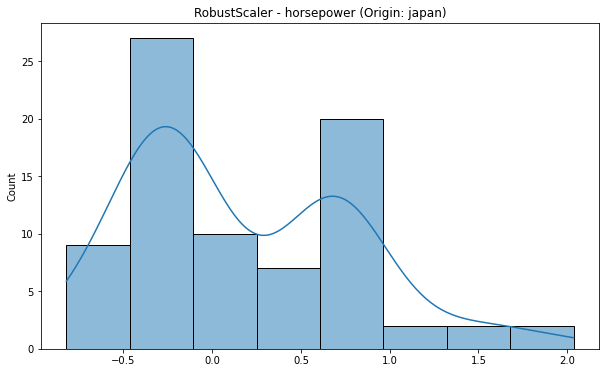

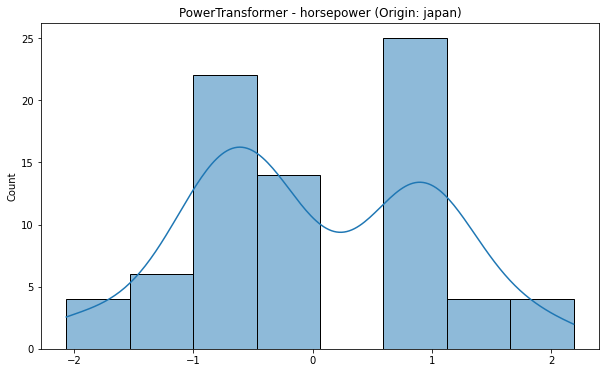

Origin: usa, Column: horsepower


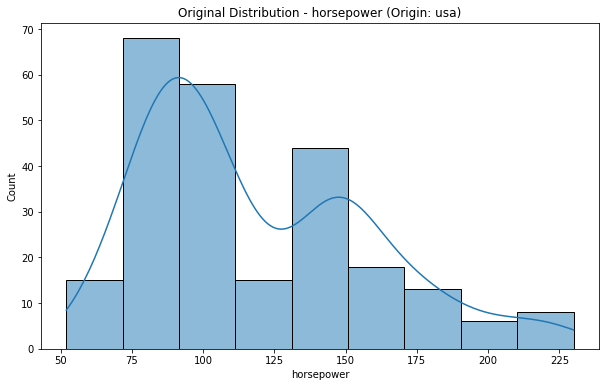

Shapiro-Wilk Test: p-value = 0.00000
horsepower is not normally distributed for origin usa.


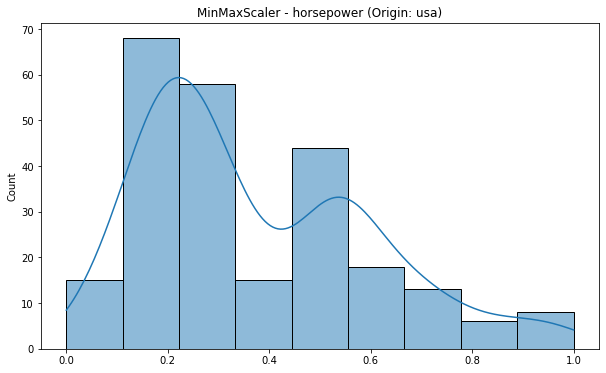

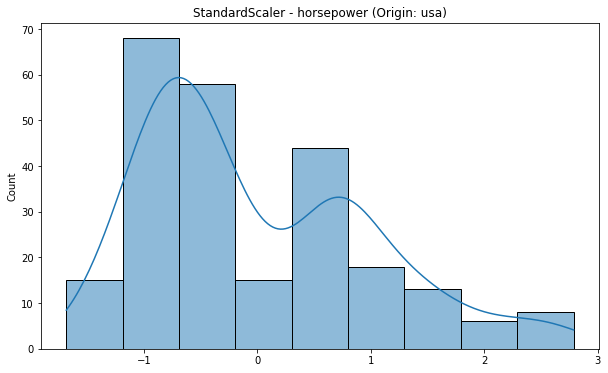

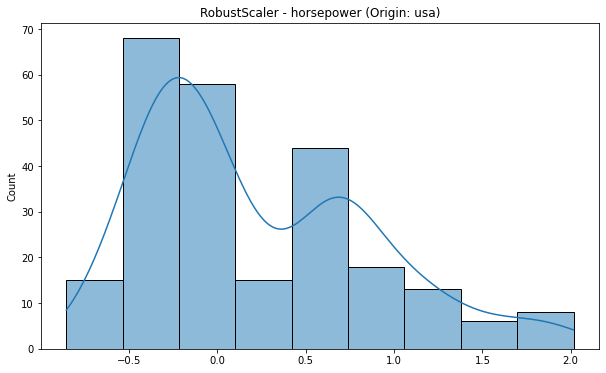

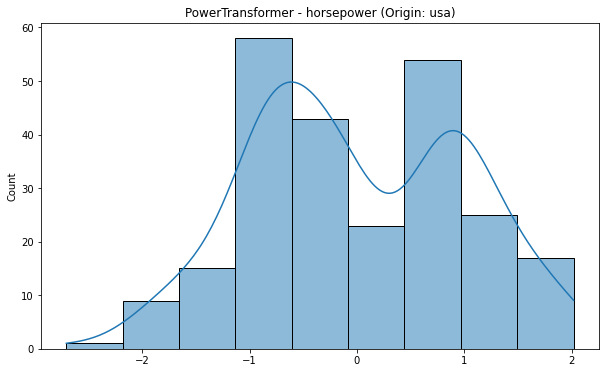

    origin            scaler          mean       std
0   europe      MinMaxScaler  3.972279e-01  0.229990
1   europe    StandardScaler -1.665335e-16  1.000000
2   europe      RobustScaler  2.004357e-01  0.988104
3   europe  PowerTransformer  1.371452e-16  1.000000
4    japan      MinMaxScaler  3.479430e-01  0.221326
5    japan    StandardScaler -5.621382e-17  1.000000
6    japan      RobustScaler  1.726944e-01  0.632359
7    japan  PowerTransformer -2.309264e-14  1.000000
8      usa      MinMaxScaler  3.766797e-01  0.223687
9      usa    StandardScaler -1.160070e-16  1.000000
10     usa      RobustScaler  2.265964e-01  0.642198
11     usa  PowerTransformer  4.785288e-15  1.000000
Origin: europe, Column: weight


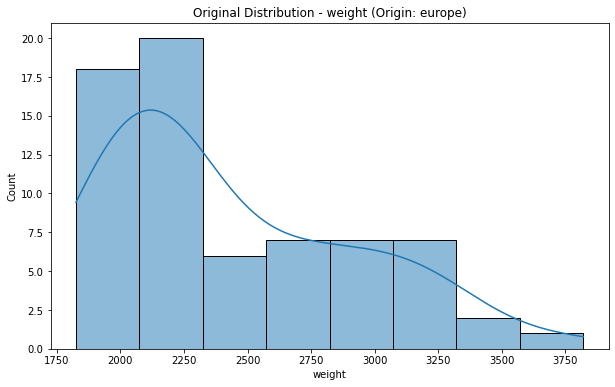

Shapiro-Wilk Test: p-value = 0.00014
weight is not normally distributed for origin europe.


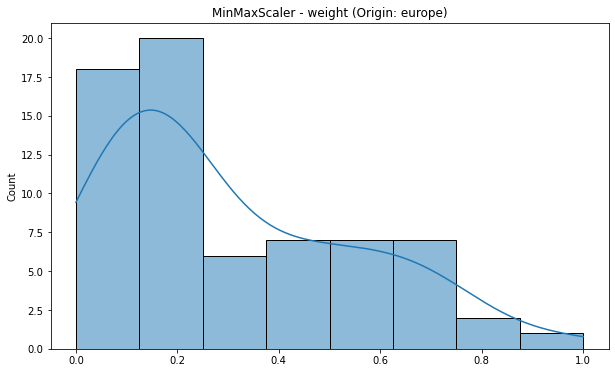

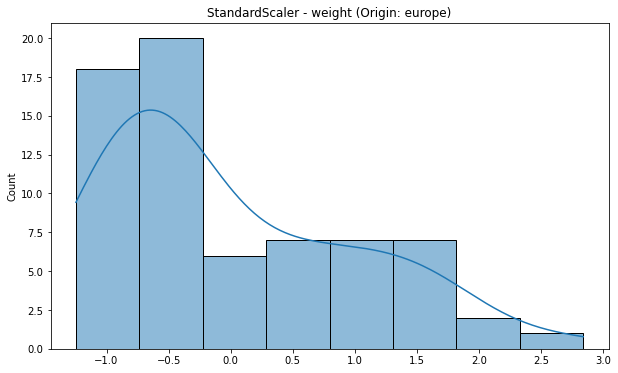

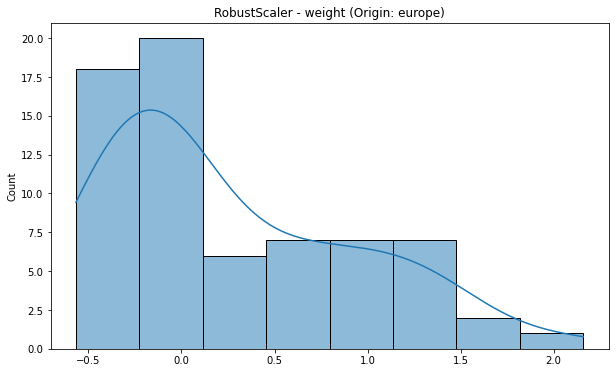

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:3237: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())


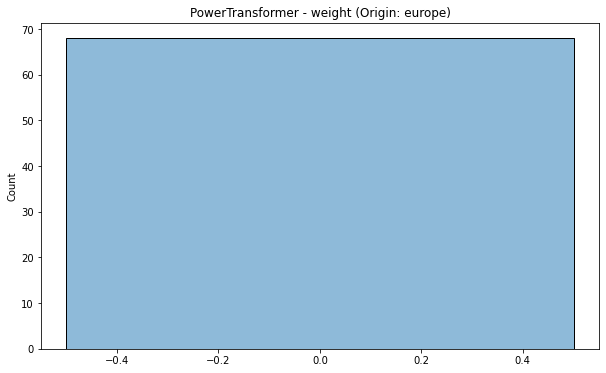

Origin: japan, Column: weight


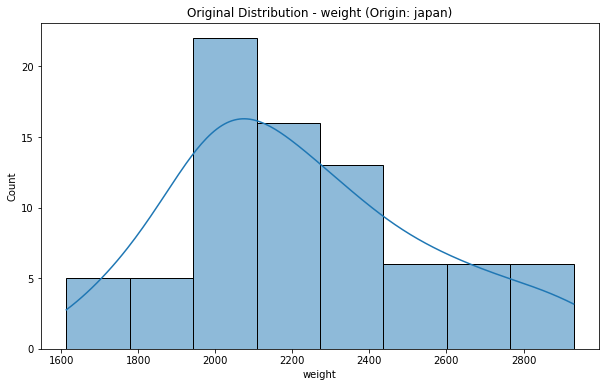

Shapiro-Wilk Test: p-value = 0.02041
weight is not normally distributed for origin japan.


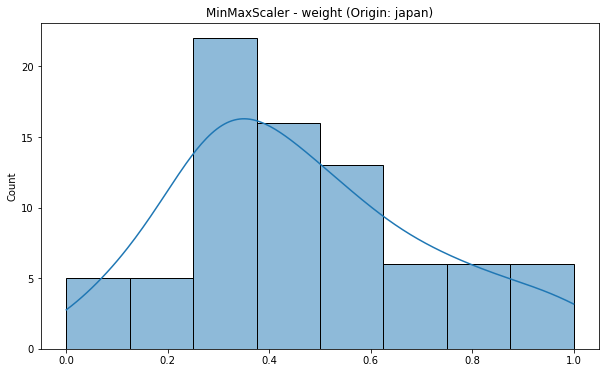

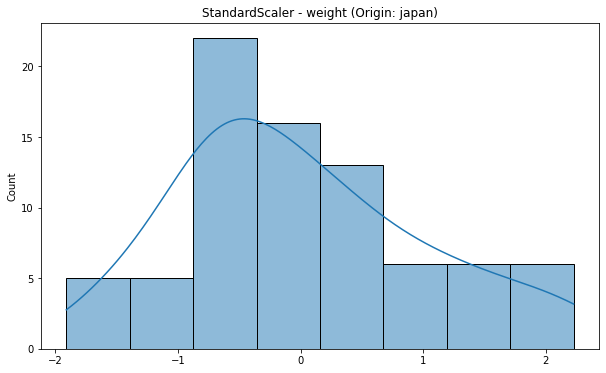

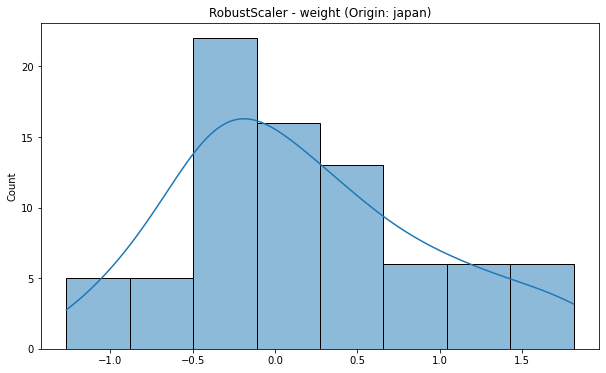

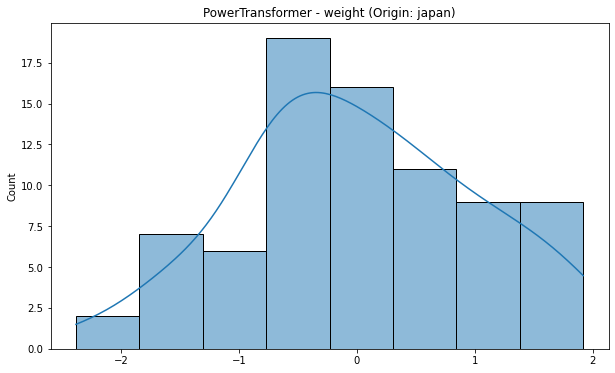

Origin: usa, Column: weight


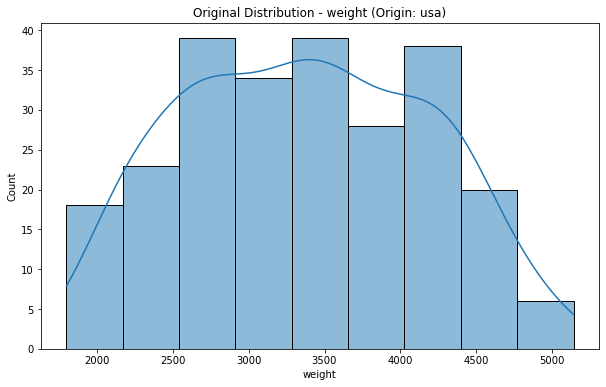

Shapiro-Wilk Test: p-value = 0.00033
weight is not normally distributed for origin usa.


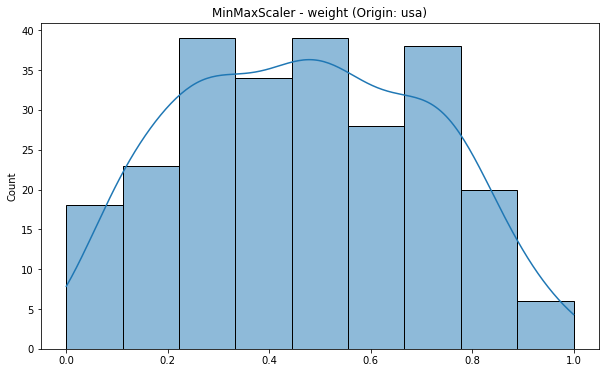

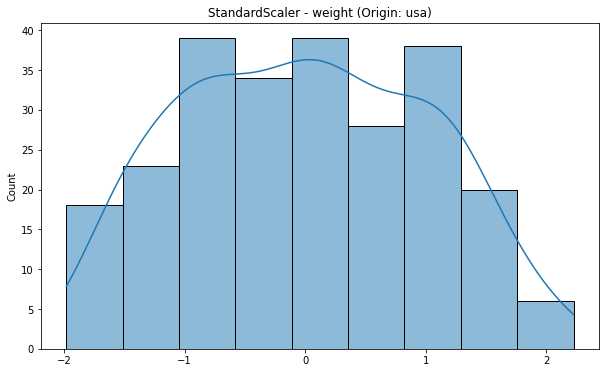

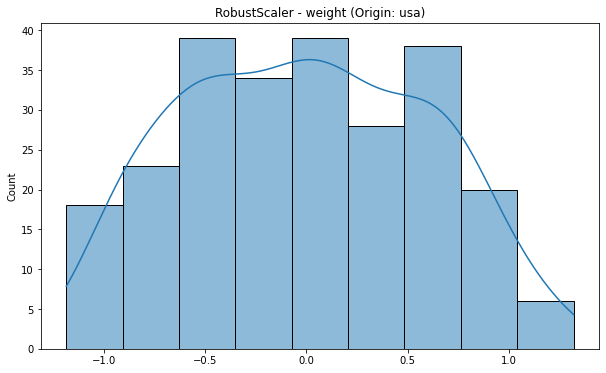

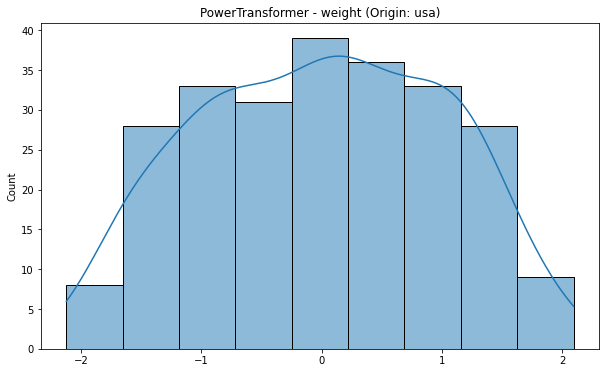

    origin            scaler          mean       std
0   europe      MinMaxScaler  3.049978e-01  0.244704
1   europe    StandardScaler -6.693992e-17  1.000000
2   europe      RobustScaler  2.643041e-01  0.666918
3   europe  PowerTransformer  0.000000e+00  0.000000
4    japan      MinMaxScaler  4.618283e-01  0.241809
5    japan    StandardScaler -1.180490e-16  1.000000
6    japan      RobustScaler  1.549189e-01  0.744941
7    japan  PowerTransformer  7.337028e-14  1.000000
8      usa      MinMaxScaler  4.708053e-01  0.237641
9      usa    StandardScaler  1.160070e-16  1.000000
10     usa      RobustScaler -6.374685e-03  0.594548
11     usa  PowerTransformer  1.740105e-16  1.000000


In [7]:
# 데이터 분포 확인 함수
def plot_distribution(data, title):
    plt.figure(figsize=(10, 6))
    sns.histplot(data, kde=True)
    plt.title(title)
    plt.show()

# origin별로 분포 확인 및 스케일링
def analyze_and_scale(data, column, origin_column):
    results = []
    scaler_methods = {
        "MinMaxScaler": MinMaxScaler(),
        "StandardScaler": StandardScaler(),
        "RobustScaler": RobustScaler(),
        "PowerTransformer": PowerTransformer(method='yeo-johnson')
    }

    for origin, group in data.groupby(origin_column):
        print(f"Origin: {origin}, Column: {column}")
        original_data = group[column]
        
        # 원본 데이터 분포
        plot_distribution(original_data, f"Original Distribution - {column} (Origin: {origin})")

        # 정규성 검정
        stat, p_value = shapiro(original_data)
        print(f"Shapiro-Wilk Test: p-value = {p_value:.5f}")

        if p_value < 0.05:
            print(f"{column} is not normally distributed for origin {origin}.")
        else:
            print(f"{column} is normally distributed for origin {origin}.")

        # 스케일링 적용
        for method_name, scaler in scaler_methods.items():
            scaled_data = scaler.fit_transform(original_data.values.reshape(-1, 1)).flatten()
            plot_distribution(scaled_data, f"{method_name} - {column} (Origin: {origin})")
            results.append({
                "origin": origin,
                "scaler": method_name,
                "mean": np.mean(scaled_data),
                "std": np.std(scaled_data)
            })

    return pd.DataFrame(results)

# 분석 및 스케일링 실행
columns_to_analyze = ['mpg', 'horsepower', 'weight']
for col in columns_to_analyze:
    result_df = analyze_and_scale(mpg, col, 'origin')
    print(result_df)